In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [2]:
data = pd.read_parquet("../widebinaries/data/merges/ngf21_merged.pqt").query("""
    teff_thick < 49900 & 7.21 < logg_thick < 8.99
""")


In [3]:
def mass_from_loggteff(loggarray : np.array, teffarray : np.array, 
                       low_model = 'be', mid_model = 'be', high_model = 'be',
                       atm_type = 'H') -> np.array:
    """compute the radial velocity from radius and effective temperature
    """
    mass_sun, radius_sun, newton_G, speed_light = 1.9884e30, 6.957e8, 6.674e-11, 299792458
    font_model = WD_models.load_model(low_model, mid_model, high_model, atm_type) 
    g_acc = (10**font_model['logg'])/100
    rsun = np.sqrt(font_model['mass_array'] * mass_sun * newton_G / g_acc) / radius_sun
    rad_teff_to_mass = WD_models.interp_xy_z_func(x = font_model['logg'], y = 10**font_model['logteff'],\
                                                z = font_model['mass_array'], interp_type = 'linear')
    return rad_teff_to_mass(loggarray, teffarray)

function = np.where(data["PDA"] > 0.5, "H", "He")
mH = function == "H"
mHe = function == "He"

# ensure column exists
data["mass_best"] = np.nan

data.loc[mH, "mass_best"] = mass_from_loggteff(
    data.loc[mH, "logg_best"].to_numpy(),
    data.loc[mH, "teff_best"].to_numpy(),
    atm_type="H"
)

data.loc[mHe, "mass_best"] = mass_from_loggteff(
    data.loc[mHe, "logg_best"].to_numpy(),
    data.loc[mHe, "teff_best"].to_numpy(),
    atm_type="He"
)
len(data)

8984

In [4]:
def covariance_ellipse(x, y, n_std=1.0, center=None, **kwargs):
    """Return a matplotlib Ellipse representing the n_std covariance ellipse"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)

    # sort eigenvalues/vectors
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # ellipse parameters
    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    if center is None:
        center = (np.mean(x), np.mean(y))

    return patches.Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

def plot_dataset(xx, yy, ax, xlims, ylims, 
                 xlabel="$\\Delta \\log g$ [\\%]",
                 ylabel="$\\Delta T_\\text{eff}$ [\\%]"):
    ax.hexbin(xx, yy, bins="log", cmap="managua", gridsize=200)

    confidence_ellipses = [3, 5, 10]
    for val in confidence_ellipses:
        circle = patches.Circle((0, 0), val, edgecolor='blue', facecolor='none', ls = '-', linewidth=2, label='')
        ax.add_patch(circle)
    #sigma_ellipses = [1, 2, 3]
    #for val in sigma_ellipses:
    #    ell = covariance_ellipse(xx, yy, n_std=val, color="k", linewidth=2)
    #    ax.add_patch(ell)

    ax.text(
        0.45, 0.25,
        rf"$\langle \Delta T_\mathrm{{eff}} \rangle = "
        rf"{np.mean(yy):1.2f} \pm {np.std(yy):1.2f}\%$"
        "\n\n"
        rf"$\langle \Delta \log g \rangle = "
        rf"{np.mean(xx):1.2f} \pm {np.std(xx):1.2f}\%$",
        color="k",
        ha="left",
        va="top",
        fontsize=16,
        transform=ax.transAxes
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xlim(xlims[0], xlims[1])
    ax.set_ylim(ylims[0], ylims[1])


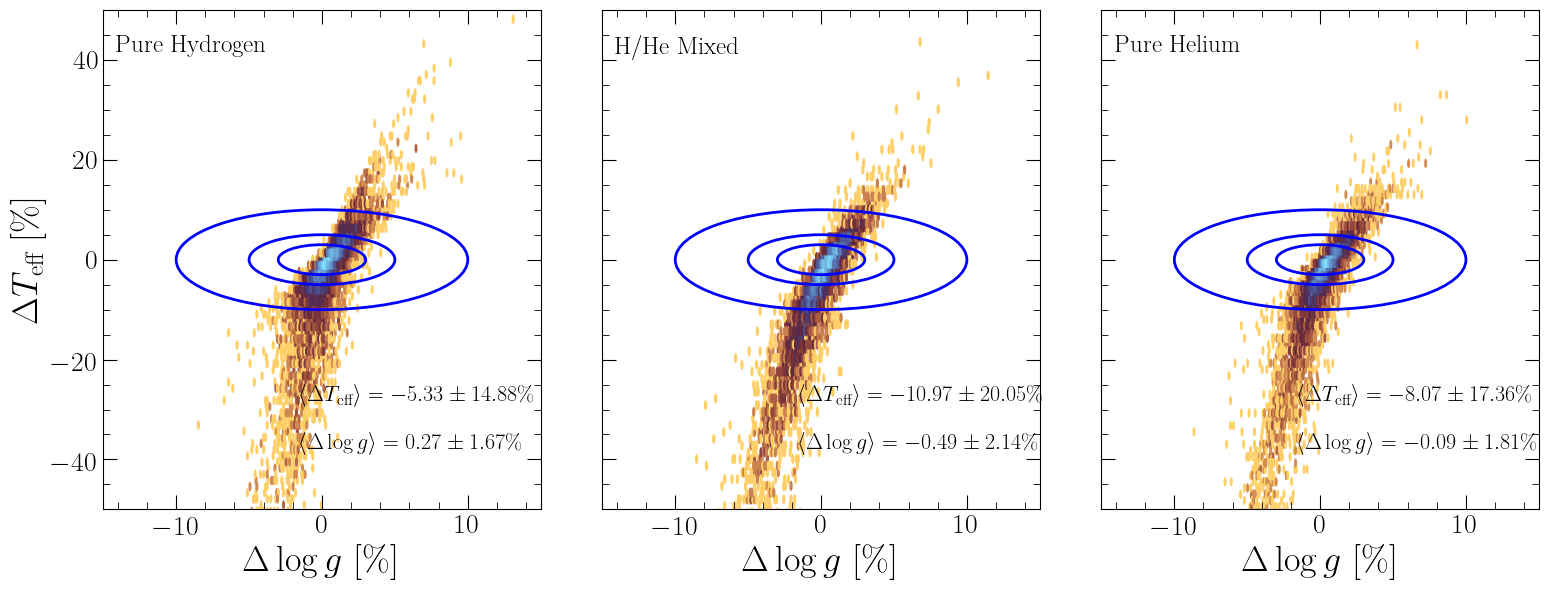

In [5]:
fig, ax = plt.subplots(ncols=3, figsize=(16,6), sharey=True)

mask = data.mass_best > 0.45

teff_pct_err_thick = 100*(data.teff_thick - data.TeffH) / data.teff_thick
logg_pct_err_thick = 100*(data.logg_thick - data.loggH) / data.logg_thick
plot_dataset(logg_pct_err_thick[mask], teff_pct_err_thick[mask], ax[0], (-15, 15), (-50, 50),)
ax[0].text(
    0.03, 0.95, rf"Pure Hydrogen",
    ha="left", va="top",
    fontsize=18, transform=ax[0].transAxes
)

teff_pct_err_mixed = 100*(data.teff_mixed - data.Teffmix) / data.teff_mixed
logg_pct_err_mixed = 100*(data.logg_mixed - data.loggmix) / data.logg_mixed
plot_dataset(logg_pct_err_mixed[mask], teff_pct_err_mixed[mask], ax[1], (-15, 15), (-50, 50),
             ylabel="")
ax[1].text(
    0.03, 0.95, rf"H/He Mixed",
    ha="left", va="top",
    fontsize=18, transform=ax[1].transAxes
)

teff_pct_err_thin = 100*(data.teff_thin - data.TeffHe) / data.teff_thin
logg_pct_err_thin = 100*(data.logg_thin - data.loggHe) / data.logg_thin
plot_dataset(logg_pct_err_thin[mask], teff_pct_err_thin[mask], ax[2], (-15, 15), (-50, 50),
             ylabel="")
ax[2].text(
    0.03, 0.95, rf"Pure Helium",
    ha="left", va="top",
    fontsize=18, transform=ax[2].transAxes
)

fig.tight_layout()
fig.savefig("figures/comparison_ngf21.pdf")

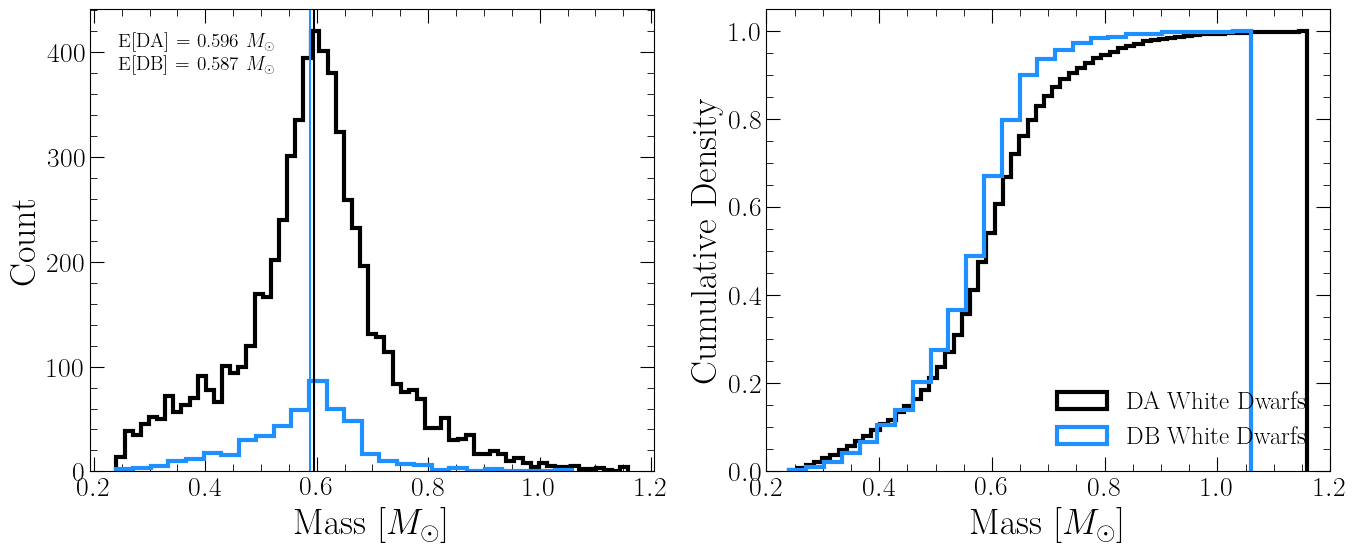

In [6]:
data_da = data.query("PDA > 0.8")
data_db = data.query("PDB > 0.8")

fig, ax = plt.subplots(ncols=2, figsize=(16, 6))

ax[0].hist(data_da.mass_best, histtype="step", linewidth=3, color="k", label="DA White Dwarfs");
ax[0].hist(data_db.mass_best, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs");

mu_da = np.median(data_da.mass_best)
mu_db = np.median(data_db.mass_best) 

ax[0].axvline(mu_da, c='k')
ax[0].axvline(mu_db, c='dodgerblue')

ax[0].text(
    0.05, 0.95,
    fr"E[DA] = {mu_da:.3f} $M_\odot$" "\n" fr"E[DB] = {mu_db:.3f} $M_\odot$",
    transform=ax[0].transAxes,
    va="top",
    ha="left",
    fontsize=14,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)   
)

ax[0].set_xlabel("Mass [$M_\\odot$]")
ax[0].set_ylabel("Count")

ax[1].hist(data_da.mass_best, histtype="step", linewidth=3, color="k", label="DA White Dwarfs",  cumulative=True, density=True);
ax[1].hist(data_db.mass_best, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs",  cumulative=True, density=True);
ax[1].set_xlim(0.2, 1.2)
ax[1].set_xlabel("Mass [$M_\\odot$]")
ax[1].set_ylabel("Cumulative Density")
ax[1].legend(framealpha=0)


In [7]:
crys = pd.read_csv("../widebinaries/data/crystallization.csv")

model = WD_models.load_model(low_mass_model='Bedard2020',
                             middle_mass_model='Bedard2020',
                             high_mass_model='Bedard2020',
                             atm_type='H',
                             HR_bands=('bp3-rp3', 'G3'))

logg_20pct = model["HR_to_logg"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
teff_20pct = 10**model["HR_to_logteff"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())

logg_80pct = model["HR_to_logg"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
teff_80pct = 10**model["HR_to_logteff"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())

7.991792921907303 0.0026330126119372345


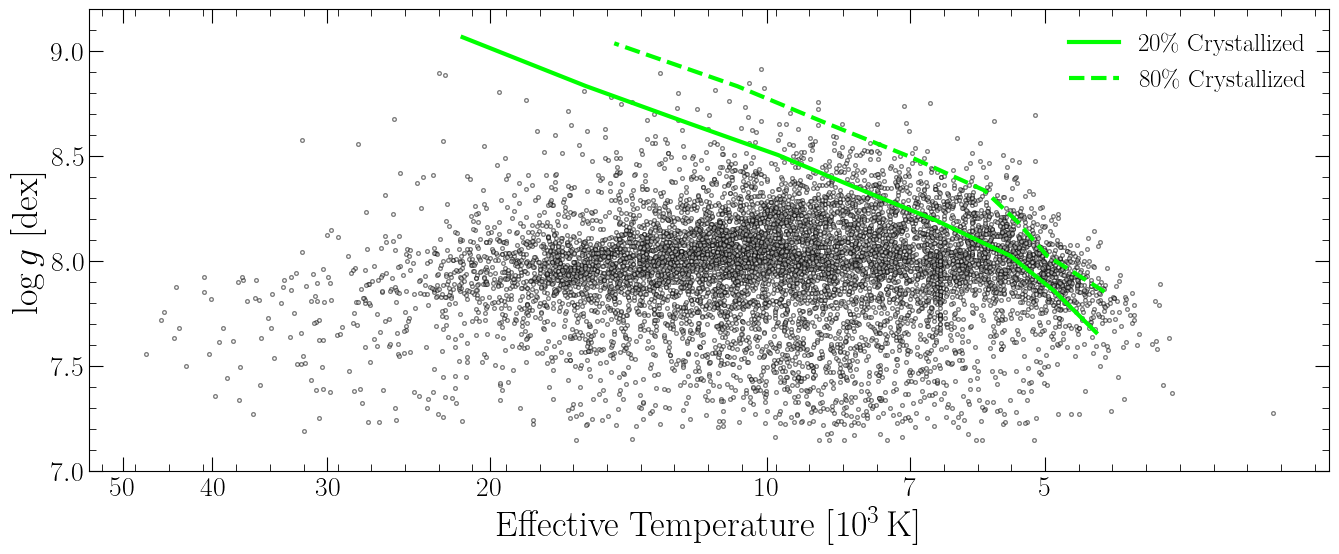

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(np.log10(data.teff_best), 
           data.logg_best, 
           c='white', edgecolor="k", 
           alpha=0.5, s=7, 
           rasterized=True)
#ax.hexbin(np.log10(data.teff_best + np.random.uniform(0, data.e_teff_best, size=len(data))), 
#           data.logg_best + np.random.uniform(0, data.e_logg_best, size=len(data)), 
#           bins="log", gridsize=150, cmap="cividis")
ax.plot(np.log10(teff_20pct), logg_20pct, c="lime", lw=3, label="20\\% Crystallized")
ax.plot(np.log10(teff_80pct), logg_80pct, c="lime", ls="--", lw=3, label="80\\% Crystallized")
ax.invert_xaxis()
leg = ax.legend(frameon=True,
    facecolor="white",
    framealpha=0.8
)
leg.get_frame().set_edgecolor("none")

print(data.logg_best.median(), data.logg_best.std() / np.sqrt(len(data)))
#ax.axhline(data.logg_best.median(), c="k", lw=2, ls=":")

ticks_kK = np.array([50, 40, 30, 20, 10, 7, 5])   # in 10^3 K
tick_locs = np.log10(ticks_kK * 1e3)
ax.set_xticks(tick_locs)
ax.set_xticklabels([f"{t:g}" for t in ticks_kK])
ax.set_xlabel(r"Effective Temperature $[10^3\,\mathrm{K}]$")
ax.set_ylabel(r"$\log g$ [dex]")
ax.set_ylim(7, 9.2)

fig.savefig("figures/kieldiagram.pdf")

In [9]:
from wdwarfdate.wdwarfdate import WhiteDwarf

data_ages = pd.read_parquet("../omnidwarf/merges/wbinary_ages_gyro_thick.pqt").reset_index()


function = np.where(data_ages["PDA"] > 0.5, "H", "He")
mH = function == "H"
mHe = function == "He"

# ensure column exists
data_ages["mass_best"] = np.nan

data_ages.loc[mH, "mass_best"] = mass_from_loggteff(
    data_ages.loc[mH, "logg_best"].to_numpy(),
    data_ages.loc[mH, "teff_best"].to_numpy(),
    atm_type="H"
)

data_ages.loc[mHe, "mass_best"] = mass_from_loggteff(
    data_ages.loc[mHe, "logg_best"].to_numpy(),
    data_ages.loc[mHe, "teff_best"].to_numpy(),
    atm_type="He"
)

data_ages["wd_age"] = 10**(data_ages["log_age_best"] - 9)
data_ages["wd_age_lo"] = 10**(data_ages["log_age_lo_best"] - 9)
data_ages["wd_age_hi"] = 10**(data_ages["log_age_hi_best"] - 9)

data_ages["wd_cool_age"] = 10**(data_ages["log_age_cool_best"] - 9)
data_ages["wd_cool_age_lo"] = 10**(data_ages["log_age_cool_lo_best"] - 9)
data_ages["wd_cool_age_hi"] = 10**(data_ages["log_age_cool_hi_best"] - 9)

In [10]:
chiti_data = pd.read_csv("../omnidwarf/data/wdms_gyro_chiti.csv")
#data_ages = pd.merge(data_ages, chiti_data, on="wd_source_id")

In [11]:
mask = (data_ages["mass_best"] > 0.63)

### real datapoints
x = data_ages.loc[mask, "wd_age"].to_numpy()
xlo = x - data_ages.loc[mask, "wd_age_lo"].to_numpy()
xhi = data_ages.loc[mask, "wd_age_hi"].to_numpy() - x

y = data_ages.loc[mask, "Age"].to_numpy()
ylo = np.abs(data_ages.loc[mask, "e_Age_2a"].to_numpy())
yhi = data_ages.loc[mask, "E_Age_2"].to_numpy()

### lower bounds
x_cool = data_ages.loc[~mask, "wd_cool_age"].to_numpy()
xlo_cool = x_cool - data_ages.loc[~mask, "wd_cool_age_lo"].to_numpy()
xhi_cool = data_ages.loc[~mask, "wd_cool_age_hi"].to_numpy() - x_cool

y_cool = data_ages.loc[~mask, "Age"].to_numpy()
ylo_cool = np.abs(data_ages.loc[~mask, "e_Age_2a"].to_numpy())
yhi_cool = data_ages.loc[~mask, "E_Age_2"].to_numpy()

In [12]:
len(x), len(x_cool), len(x) + len(x_cool)

(46, 69, 115)

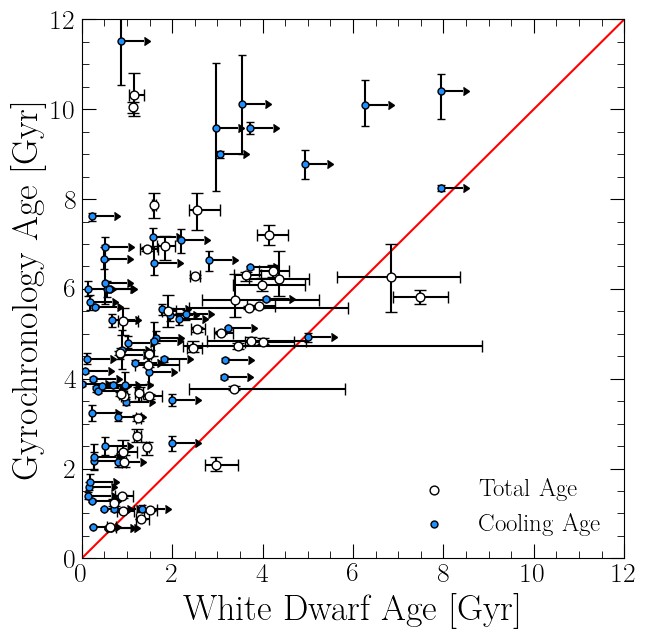

In [13]:
plt.scatter(x, y, c = 'white', edgecolor = 'k', zorder = 3, label="Total Age", s=40)
plt.errorbar(x, y, xerr=[xlo, xhi], yerr=[ylo, yhi], fmt='None', c = 'k', capsize=4, zorder = 2)

plt.scatter(x_cool, y_cool, c="dodgerblue", edgecolor="k", zorder=2, label="Cooling Age")
plt.errorbar(x_cool, y_cool,
             xerr=0.5,                 # small visual stub (constant)
             xlolims=True,             # <-- arrow to the right
             yerr=[ylo_cool, yhi_cool],
             fmt="none", c="k", capsize=3, zorder=1)

plt.plot([-5, 20], [-5, 20], c = 'red', zorder = 0)
plt.xlim(0, 12) ; plt.ylim(0, 12)

plt.xlabel("White Dwarf Age [Gyr]")
plt.ylabel("Gyrochronology Age [Gyr]")
plt.legend(framealpha=0)

plt.savefig("figures/gyro_comparison.pdf")

In [14]:
data_wdwd = pd.read_parquet("../omnidwarf/merges/ages_heintz2022.pqt")

data_wdwd["mass_pri"] = np.nan
data_wdwd.loc[:, "mass_pri"] = mass_from_loggteff(
    data_wdwd.loc[:, "logg_best_pri"].to_numpy(),
    data_wdwd.loc[:, "teff_best_pri"].to_numpy(),
    atm_type="He"
)

data_wdwd["mass_sec"] = np.nan
data_wdwd.loc[:, "mass_sec"] = mass_from_loggteff(
    data_wdwd.loc[:, "logg_best_sec"].to_numpy(),
    data_wdwd.loc[:, "teff_best_sec"].to_numpy(),
    atm_type="H"
)


In [15]:
data_wdwd["wd_age_pri"] = 10**(data_wdwd["log_age_best_pri"] - 9)
data_wdwd["wd_age_lo_pri"] = 10**(data_wdwd["log_age_lo_best_pri"] - 9)
data_wdwd["wd_age_hi_pri"] = 10**(data_wdwd["log_age_hi_best_pri"] - 9)

data_wdwd["wd_cool_age_pri"] = 10**(data_wdwd["log_age_cool_best_pri"] - 9)
data_wdwd["wd_cool_age_lo_pri"] = 10**(data_wdwd["log_age_cool_lo_best_pri"] - 9)
data_wdwd["wd_cool_age_hi_pri"] = 10**(data_wdwd["log_age_cool_hi_best_pri"] - 9)

data_wdwd["wd_age_sec"] = 10**(data_wdwd["log_age_best_sec"] - 9)
data_wdwd["wd_age_lo_sec"] = 10**(data_wdwd["log_age_lo_best_sec"] - 9)
data_wdwd["wd_age_hi_sec"] = 10**(data_wdwd["log_age_hi_best_sec"] - 9)

data_wdwd["wd_cool_age_sec"] = 10**(data_wdwd["log_age_cool_best_sec"] - 9)
data_wdwd["wd_cool_age_lo_sec"] = 10**(data_wdwd["log_age_cool_lo_best_sec"] - 9)
data_wdwd["wd_cool_age_hi_sec"] = 10**(data_wdwd["log_age_cool_hi_best_sec"] - 9)

data_wdwd = data_wdwd.query("(wd_age_pri < 14) & (wd_age_sec < 14)")

In [16]:
mask = (data_wdwd.mass_sec > 0.63) & (data_wdwd.mass_pri > 0.63) & (data_wdwd.MassS > 0.63)

In [17]:
## primary
x_pri = data_wdwd.loc[mask, "wd_age_pri"].to_numpy()
xlo_pri = x_pri - data_wdwd.loc[mask, "wd_age_lo_pri"].to_numpy()
xhi_pri = data_wdwd.loc[mask, "wd_age_hi_pri"].to_numpy() - x_pri

y_pri = data_wdwd.loc[mask, "TAge"].to_numpy()
ylo_pri = np.abs(data_wdwd.loc[mask, "e_TAge_1a"].to_numpy())
yhi_pri = data_wdwd.loc[mask, "E_TAge_1"].to_numpy()

## secondary
x_sec = data_wdwd.loc[mask, "wd_age_sec"].to_numpy()
xlo_sec = x_sec - data_wdwd.loc[mask, "wd_age_lo_sec"].to_numpy()
xhi_sec = data_wdwd.loc[mask, "wd_age_hi_sec"].to_numpy() - x_sec

y_sec = data_wdwd.loc[mask, "TAgeS"].to_numpy()
ylo_sec = np.abs(data_wdwd.loc[mask, "e_TAgeS_1a"].to_numpy())
yhi_sec = data_wdwd.loc[mask, "E_TAgeS_1"].to_numpy()

In [18]:
data_wdwd["age_diff"] = data_wdwd["wd_age_pri"] - data_wdwd["wd_age_sec"]
data_wdwd["e_age_diff"] = np.sqrt(
    (data_wdwd["wd_age_hi_pri"] - data_wdwd["wd_age_lo_pri"])**2/4
    + (data_wdwd["wd_age_hi_sec"] - data_wdwd["wd_age_lo_sec"])**2/4
)

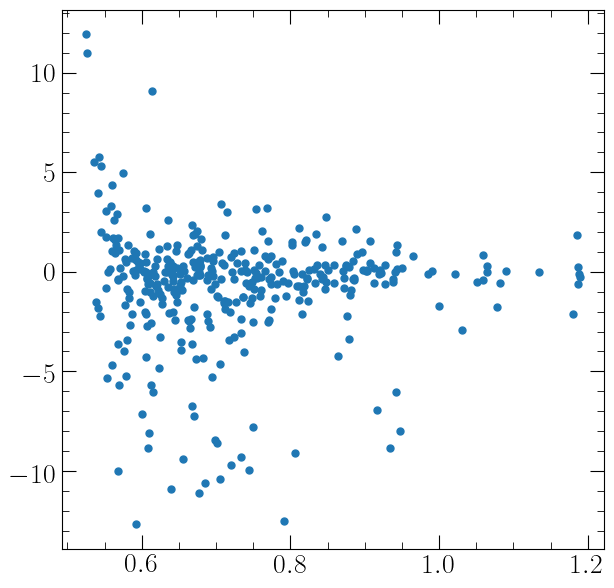

In [19]:
plt.scatter(data_wdwd.loc[:,"mass_pri"], data_wdwd.loc[:,"age_diff"])

(230,)


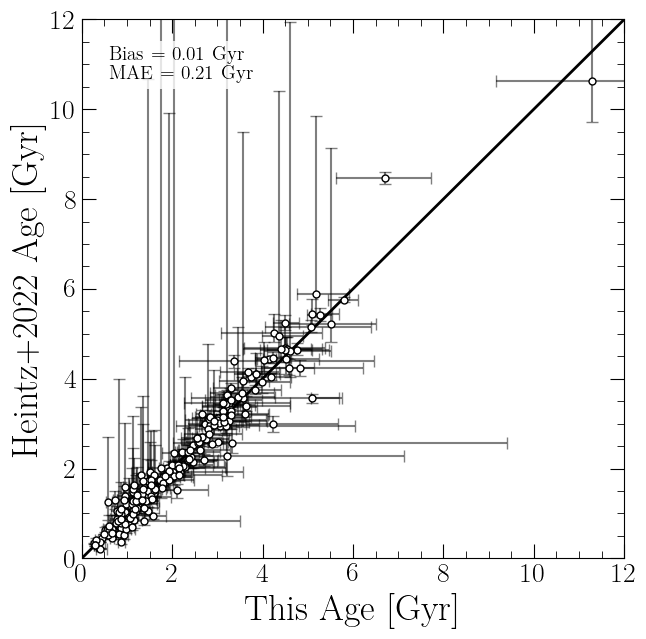

In [20]:
# residuals: y - x
res_pri = y_pri - x_pri
res_sec = y_sec - x_sec
res = np.concatenate([res_pri, res_sec])

bias = np.nanmean(res)
mae  = np.nanmean(np.abs(res))

plt.scatter(x_pri, y_pri, c = 'white', edgecolor = 'k', zorder = 1, label="Primary WD")
plt.errorbar(x_pri, y_pri, xerr=[xlo_pri, xhi_pri], yerr=[ylo_pri, yhi_pri], fmt='None', 
             c = 'k', alpha=0.5, capsize=4, zorder = 0)

plt.scatter(x_sec, y_sec, c = 'white', edgecolor = 'k', zorder = 1, label="Secondary WD")
plt.errorbar(x_sec, y_sec, xerr=[xlo_sec, xhi_sec], yerr=[ylo_sec, yhi_sec], fmt='None', 
             c = 'k', alpha=0.5, capsize=4, zorder = 0)

plt.plot([-1, 20], [-1, 20], c='k', lw=2, zorder=0)
plt.xlim(0, 12) ; plt.ylim(0, 12)

plt.xlabel("This Age [Gyr]") ; plt.ylabel("Heintz+2022 Age [Gyr]") 
#plt.legend(framealpha=0, loc='lower right')

plt.text(
    0.05, 0.95,
    fr"Bias = {bias:.2f} Gyr" "\n" fr"MAE = {mae:.2f} Gyr",
    transform=plt.gca().transAxes,
    va="top",
    ha="left",
    fontsize=14,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

print(res.shape)
plt.savefig("figures/heintz_agreement.pdf")

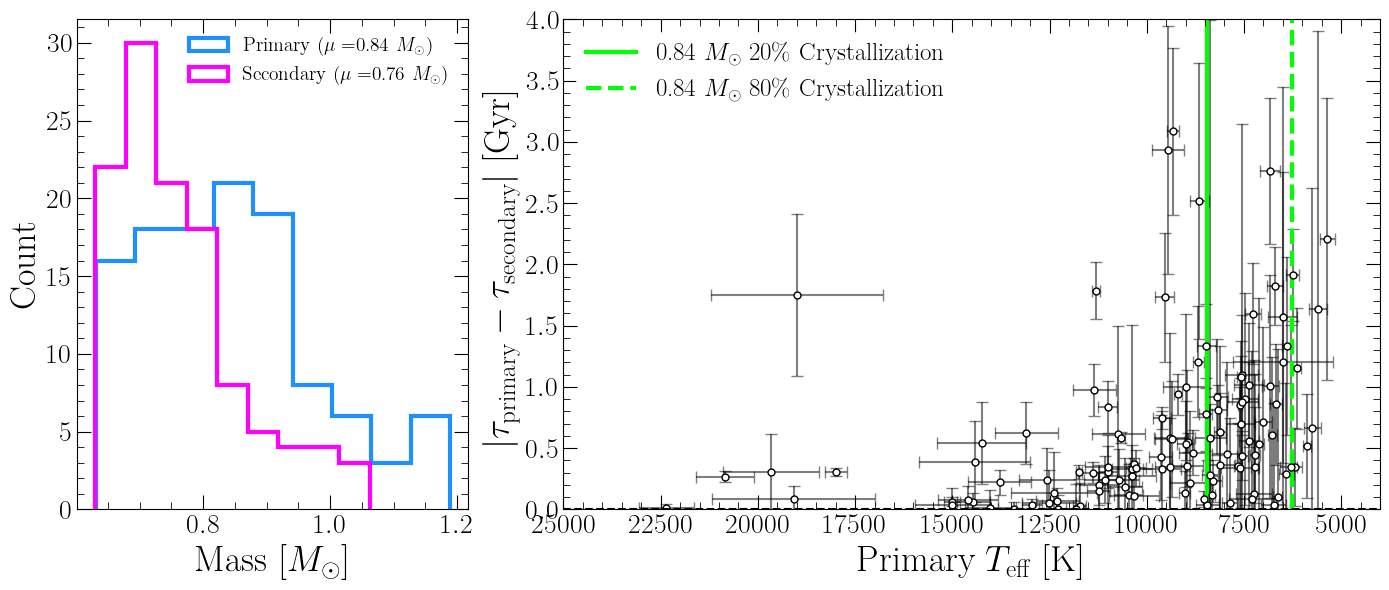

In [21]:
fig, ax = plt.subplots(ncols=2, figsize=(14,6),
    gridspec_kw={"width_ratios": [1.1, 2.3]})  # left, right)

med_mass = np.mean(data_wdwd.loc[mask, "mass_pri"])
med_massS = np.mean(data_wdwd.loc[mask, "mass_sec"])

ax[0].hist(data_wdwd.loc[mask, "mass_pri"], histtype="step", color="dodgerblue", 
           label=f"Primary ($\\mu = ${med_mass:1.2f}$~M_\\odot$)", linewidth=3)
ax[0].hist(data_wdwd.loc[mask, "mass_sec"], histtype="step", color="magenta", 
           label=f"Secondary ($\\mu = ${med_massS:1.2f}$~M_\\odot$)", linewidth=3)
ax[0].legend(framealpha=0, fontsize=14)
ax[0].set_xlabel("Mass [$M_\\odot$]")
ax[0].set_ylabel("Count")


mass_20pct = model["HR_to_mass"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
mass_80pct = model["HR_to_mass"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())

teff_20_wdwd = np.interp(med_mass, mass_20pct, teff_20pct)
teff_80_wdwd = np.interp(med_mass, mass_80pct, teff_80pct)

ax[1].scatter(data_wdwd.loc[mask,"teff_best_pri"], np.abs(data_wdwd.loc[mask,"age_diff"]),
            c="white", edgecolor="k", zorder=2)
ax[1].errorbar(data_wdwd.loc[mask,"teff_best_pri"], np.abs(data_wdwd.loc[mask,"age_diff"]), 
             xerr=data_wdwd.loc[mask,"e_teff_best_pri"], 
             yerr=data_wdwd.loc[mask,"e_age_diff"], 
             fmt='None', 
             c = 'k', alpha=0.5, capsize=4, zorder = 0)

ax[1].axhline(y=0, c="k", ls="--")
ax[1].axvline(teff_20_wdwd, c="lime", lw=3, label=f"{med_mass:1.2f} $M_\\odot$ 20\\% Crystallization", zorder=1)
ax[1].axvline(teff_80_wdwd, c="lime", lw=3, ls="--", label=f"{med_mass:1.2f} $M_\\odot$ 80\\% Crystallization", zorder=1)
leg = ax[1].legend(frameon=True,
    facecolor="white",
    framealpha=0.8
)
leg.get_frame().set_edgecolor("none")
ax[1].set_ylim(0, 4) ; ax[1].set_xlim(4000, 25000)

ax[1].set_xlabel("Primary $T_\\text{eff}$ [K]")
ax[1].set_ylabel("$|\\tau_\\text{primary} - \\tau_\\text{secondary}|$ [Gyr]")
ax[1].invert_xaxis()

fig.tight_layout()

In [22]:
med_mass

np.float64(0.844864123042009)

In [23]:
data

,gaia_dr3_source_id,teff_thick,e_teff_thick,logg_thick,e_logg_thick,covar_thick,redchi_thick,log_age_cool_thick,log_age_thick,log_age_cool_hi_thick,...,e_rmag,imag,e_imag,zmag,e_zmag,SDSSsep,SDSSspec,_RA.icrs,_DE.icrs,mass_best
0,4586503628739277312,13759.755971,687.987799,7.960292,0.079603,0,0.047649,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.520910,28.190927,0.587268
1,2158107129347694592,5086.051324,254.302566,8.060587,0.080606,0,0.104619,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.548931,60.208089,0.618678
2,6702386144325312384,9842.386727,492.119336,7.885418,0.078854,0,0.153482,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.555824,-50.570905,0.534746
3,4483974792231866624,4915.247150,245.762357,7.900496,0.079005,0,0.113845,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.601838,11.347107,0.509147
4,4273314166840237952,6055.197881,302.759894,8.130552,0.081306,0,0.115963,9.441002,9.569637,9.550000,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.631502,0.731357,0.668648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9472,2150591795574568192,4423.678098,221.183905,7.960221,0.079602,0,0.071435,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.330410,55.646991,0.556841
9473,2257245316820589568,12920.699012,646.034951,8.485703,0.084857,0,0.075241,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.331959,66.531218,0.914514
9474,2109540635598902144,18962.131010,948.106551,8.001368,0.080014,0,0.101905,7.950000,9.125328,8.051139,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.333001,39.860836,0.622638
9475,4478520321197420672,9931.293890,496.564695,7.289474,0.072895,0,0.127428,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,276.363197,8.583377,0.251351


In [24]:
data["wd_age"] = 10**(data["log_age_best"] - 9)
data["wd_age_lo"] = 10**(data["log_age_lo_best"] - 9)
data["wd_age_hi"] = 10**(data["log_age_hi_best"] - 9)

data["wd_cool_age"] = 10**(data["log_age_cool_best"] - 9)
data["wd_cool_age_lo"] = 10**(data["log_age_cool_lo_best"] - 9)
data["wd_cool_age_hi"] = 10**(data["log_age_cool_hi_best"] - 9)

3154


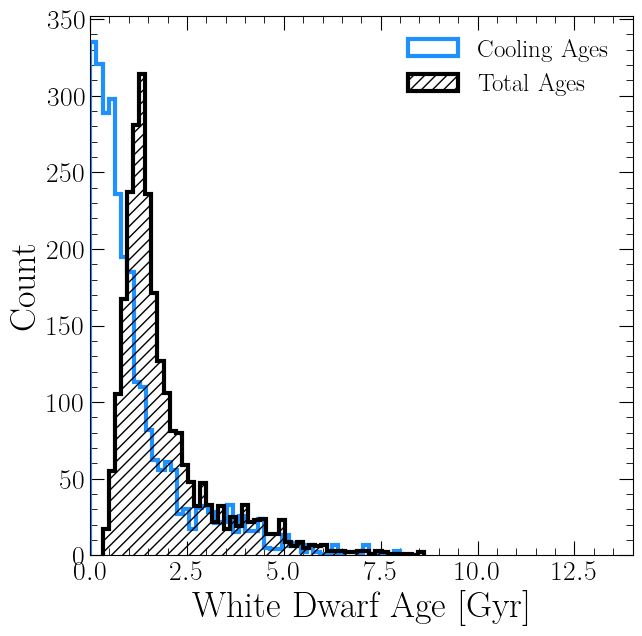

In [25]:
mask = data["mass_best"] > 0.63

print(mask.sum())

plt.hist(data.loc[:,"wd_cool_age"], histtype="step", color="dodgerblue", linewidth=3, label="Cooling Ages");
plt.hist(data.loc[mask,"wd_age"], histtype="step", color="k", linewidth=3, hatch="///", label="Total Ages");
plt.xlabel("White Dwarf Age [Gyr]") ; plt.ylabel("Count")
plt.xlim(0, 14)
plt.legend(framealpha=0)
plt.savefig("figures/age_dist.pdf")

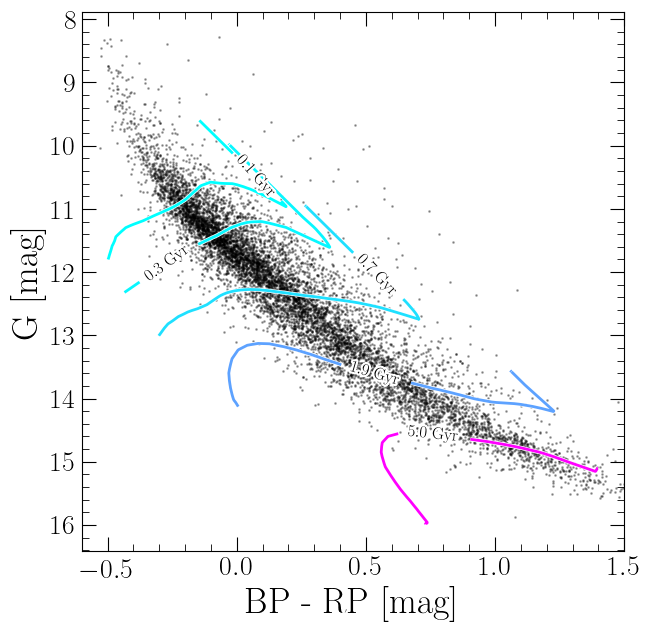

In [26]:
from matplotlib import colors, cm
from matplotlib.ticker import LogFormatter
from matplotlib import patheffects

HR_grid = (-0.6, 1.4, 0.002, 9, 16, 0.01)
model  = WD_models.load_model(
    'be', 'be', 'be', 'H', 
    HR_bands=('bp3-rp3', 'G3'),
    HR_grid=HR_grid, 
    interp_type_atm='linear',
) 

fig, ax = plt.subplots()
ax.scatter(data["BP-RP"], data["GmagCorr"] - 5*np.log10(data["rgeo"]) + 5, s=1, c="k", alpha=0.3, zorder=2, rasterized=True)
ax.invert_yaxis()

levels = np.geomspace(0.1, 5, num=5)

contour2 = ax.contour(
    model['grid_HR_to_age_cool'].T,
    levels=levels,
    extent=(HR_grid[0], HR_grid[1], HR_grid[3], HR_grid[4]),
    cmap="cool",
    linewidths=2,
    zorder=3
)
contour2.set(path_effects=[patheffects.withStroke(linewidth=3, foreground="w")])

clbls = ax.clabel(contour2, inline=True, fontsize=12,
          fmt=lambda x: f"{x:1.1f} Gyr",
          colors='k')        # force black text
plt.setp(clbls, path_effects=[
    patheffects.withStroke(linewidth=3, foreground="w")])

ax.set_xlim(-0.6, 1.5)

ax.set_xlabel(r"BP - RP [mag]")
ax.set_ylabel(r"G [mag]")

fig.savefig("figures/cmd.pdf")

In [ ]:
stellarhosts = pd.read_csv("../widebinaries/data/stellarhosts.csv", comment="#")
stellarhosts = pd.merge(data, stellarhosts, left_on="gaia_dr3_source_id", right_on="wd_source_id")
stellarhosts.loc[:, "reliable_age"] = stellarhosts.mass_best > 0.63

mask = ~stellarhosts.reliable_age
stellarhosts.loc[mask, "wd_age"] = np.nan 
stellarhosts.loc[mask, "wd_age_hi"] = np.nan 
stellarhosts.loc[mask, "wd_age_lo"] = np.nan 

In [28]:
stellarhosts[["wd_source_id", "ms_source_id","sy_pnum", "wd_cool_age", "wd_cool_age_hi", "wd_cool_age_lo", "wd_age", "wd_age_hi", "wd_age_lo"]].to_latex("exoplanets.tex")

In [29]:
def latex_ci(med, hi, lo, fmt="{:.3f}"):
    plus = hi - med
    minus = med - lo
    if np.isnan(med):
        return "-"
    else:
        return rf"${fmt.format(med)}^{{+{fmt.format(plus)}}}_{{-{fmt.format(minus)}}}$"

df = stellarhosts.copy()

df["wd_cool_age_tex"] = [
    latex_ci(m, h, l)
    for m, h, l in zip(df.wd_cool_age, df.wd_cool_age_hi, df.wd_cool_age_lo)
]

df["wd_age_tex"] = [
    latex_ci(m, h, l)
    for m, h, l in zip(df.wd_age, df.wd_age_hi, df.wd_age_lo)
]

In [30]:
df[["wd_source_id", "ms_source_id","sy_pnum","mass_best","wd_cool_age_tex", "wd_age_tex"]].to_latex(
    "exoplanets.tex",
    escape=False,   # critical so LaTeX math is not escaped
    index=False
)

In [31]:
df[["wd_source_id", "ms_source_id","sy_pnum","mass_best","teff_best","logg_best","wd_cool_age", "wd_age"]]

,wd_source_id,ms_source_id,sy_pnum,mass_best,teff_best,logg_best,wd_cool_age,wd_age
0,2645940445519931520,2645940376800212096,1,0.533281,7583.187795,7.925910,NaN,NaN
1,4984244267802428032,4984244302162168704,1,0.463517,7256.112503,7.800388,NaN,NaN
2,5602379190880667904,5602386058511578368,2,0.512275,4933.288817,7.903767,NaN,NaN
3,3693358792919145600,3693358861640279296,2,0.681513,6401.799878,8.148231,NaN,NaN
4,6160221736672454400,6160221740968692992,1,0.724293,7266.487967,8.234907,1.995262,2.502904
5,6009537829925128064,6009538585839374336,2,0.635878,10619.830011,8.056720,0.577110,1.747675
6,6018034958869558912,6018047019138644480,1,0.689920,25903.996262,8.092578,0.020334,0.640333
